In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vR73EXLbZmOQO1Ypeytc2X4PjyWMaVHAL9xVhIQhTpYDdJV7SKRhTyl0xsYIDJmrnzkHcHRXbeMaKCr/pub?output=csv"
)
# Filter the DataFrame based on beliefInAstrologyScore > 0
filtered_df = df[df["beliefInAstrologyScore"] > 0]

# Select quantitative variables
experience_data = filtered_df["astrologicalExperienceNumerical"]
answers_data = filtered_df["correctAnswersOnChallengeOutOf12"]

# Compute Pearson's r
r, _ = pearsonr(experience_data, answers_data)

print("Pearson's r (astrological experience & correct answers): %.3f" % r)

# Compute r for confounding variable
belief_data = filtered_df["beliefInAstrologyScore"]
r2, _2 = pearsonr(belief_data, experience_data)
print("Pearson's r (astrological experience & belief in astrology): %.3f" % r2)


Pearson's r (astrological experience & correct answers): -0.009
Pearson's r (astrological experience & belief in astrology): 0.418


Summary Statistics for 'astrologicalExperienceNumerical':
Sample Size: 109
Sample Mean: 2.17
Median: 2
Mode: 2
Range: 5
Sample Standard Deviation: 1.20



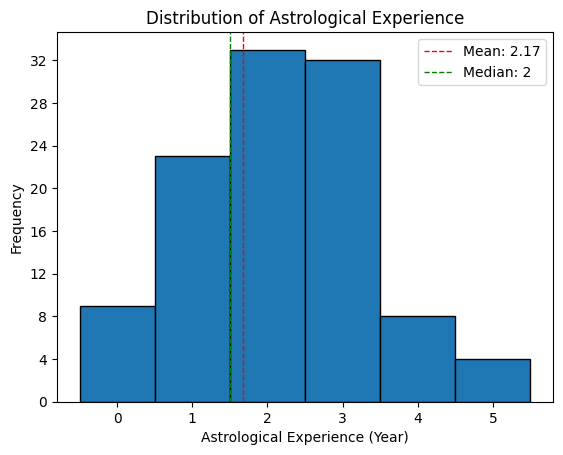

In [ ]:
import statistics
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Calculate basic summary statistics
sample_size = len(experience_data)
sample_mean = statistics.mean(experience_data)
sample_median = statistics.median(experience_data)
sample_mode = statistics.mode(experience_data)
sample_range = max(experience_data) - min(experience_data)
sample_stdev = statistics.stdev(experience_data) if sample_size > 1 else 0 # Handle case for single element list

# Print the results
print("Summary Statistics for 'astrologicalExperienceNumerical':")
print(f"Sample Size: {sample_size}")
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Median: {sample_median}")
print(f"Mode: {sample_mode}")
print(f"Range: {sample_range}")
print(f"Sample Standard Deviation: {sample_stdev:.2f}")
print()

# Plot the distribution
max_experience = int(experience_data.max())
bins = range(max_experience + 2) # Bins from 0 to max_experience + 1

plt.hist(experience_data, bins=bins, edgecolor="black")
plt.xlabel("Astrological Experience (Year)")
plt.ylabel("Frequency")
plt.xticks([i + 0.5 for i in range(max_experience + 1)], range(max_experience + 1)) # Center labels
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True)) # Set y-axis to integer ticks
plt.title("Distribution of Astrological Experience")

# Add mean and median lines
plt.axvline(sample_mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {sample_mean:.2f}')
plt.axvline(sample_median, color='green', linestyle='dashed', linewidth=1, label=f'Median: {sample_median}')
plt.legend()

plt.show()

Summary Statistics for 'correctAnswersOnChallengeOutOf12' (where beliefInAstrologyScore > 0):
Sample Size: 109
Sample Mean: 2.50
Median: 2
Mode: 2
Range: 5
Sample Standard Deviation: 1.39



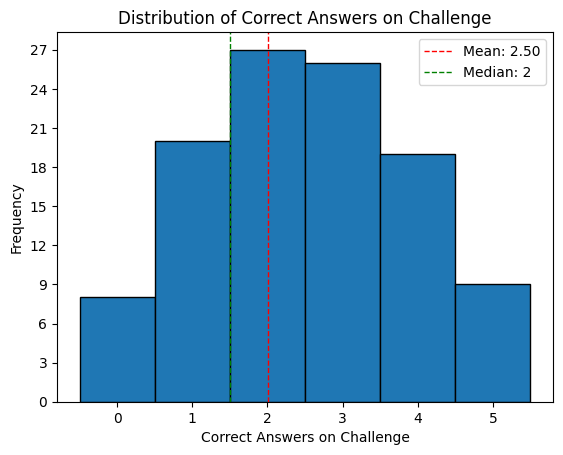

In [ ]:
import statistics
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Calculate basic summary statistics
sample_size = len(answers_data)
sample_mean = statistics.mean(answers_data)
sample_median = statistics.median(answers_data)
sample_mode = statistics.mode(answers_data)
sample_range = max(answers_data) - min(answers_data)
sample_stdev = statistics.stdev(answers_data) if sample_size > 1 else 0

# Print the results
print("Summary Statistics for 'correctAnswersOnChallengeOutOf12' (where beliefInAstrologyScore > 0):")
print(f"Sample Size: {sample_size}")
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Median: {sample_median}")
print(f"Mode: {sample_mode}")
print(f"Range: {sample_range}")
print(f"Sample Standard Deviation: {sample_stdev:.2f}")
print()

# Plot the distribution
max_answers = int(answers_data.max())
bins = range(max_answers + 2) # Bins from 0 to max_answers + 1

plt.hist(answers_data, bins=bins, edgecolor="black")
plt.xlabel("Correct Answers on Challenge")
plt.ylabel("Frequency")
plt.xticks([i + 0.5 for i in range(max_answers + 1)], range(max_answers + 1)) # Center labels
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True)) # Set y-axis to integer ticks
plt.title("Distribution of Correct Answers on Challenge")

# Add mean and median lines
plt.axvline(sample_mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {sample_mean:.2f}')
plt.axvline(sample_median, color='green', linestyle='dashed', linewidth=1, label=f'Median: {sample_median}')
plt.legend()

plt.show()

Pearson's r between Astrological Experience and Correct Answers: -0.009


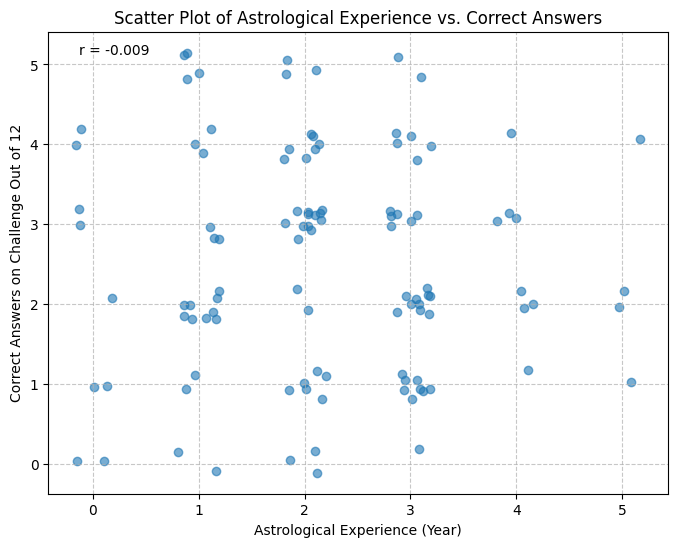

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Pearson's r between Astrological Experience and Correct Answers: {r:.3f}")

# Create a scatter plot with jitter, without a regression line
plt.figure(figsize=(8, 6))
sns.regplot(x=experience_data, y=answers_data, scatter_kws={'alpha':0.6}, fit_reg=False, x_jitter=0.2, y_jitter=0.2)
plt.title("Scatter Plot of Astrological Experience vs. Correct Answers")
plt.xlabel("Astrological Experience (Year)")
plt.ylabel("Correct Answers on Challenge Out of 12")
plt.grid(True, linestyle='--', alpha=0.7)

# Annotate the plot with the 'r' value
plt.text(0.05, 0.95, f'r = {r:.3f}', transform=plt.gca().transAxes)
plt.show()

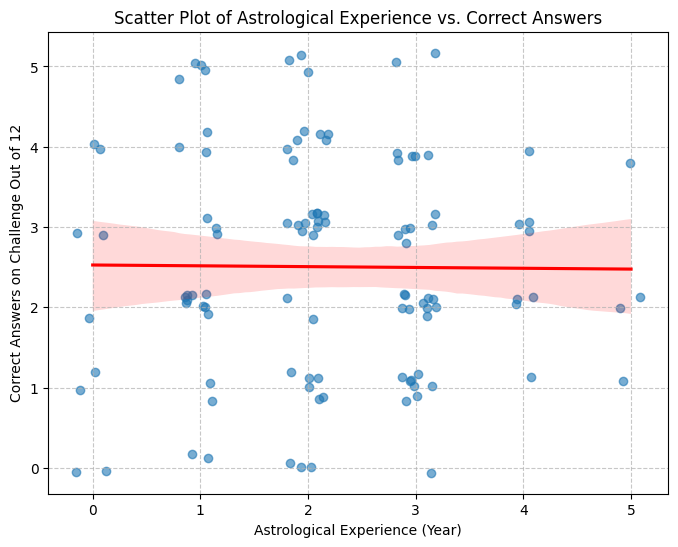

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Create a scatter plot with jitter https://seaborn.pydata.org/generated/seaborn.regplot.html
plt.figure(figsize=(8, 6))
sns.regplot(x=experience_data, y=answers_data, scatter_kws={'alpha':0.6}, line_kws={'color':'red'}, x_jitter=0.2, y_jitter=0.2)
plt.title("Scatter Plot of Astrological Experience vs. Correct Answers")
plt.xlabel("Astrological Experience (Year)")
plt.ylabel("Correct Answers on Challenge Out of 12")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


--- REGRESSION SUMMARY ---
Correlation (r): -0.0088
R-squared:       0.0001
Slope (b1):      -0.0102
Intercept (b0):  2.5268
Standard Error:  0.1115
95% CI:          [-0.2313, 0.2109]
p-value:         0.9273
--------------------------
Result: Not Statistically Significant (Fail to Reject Null)


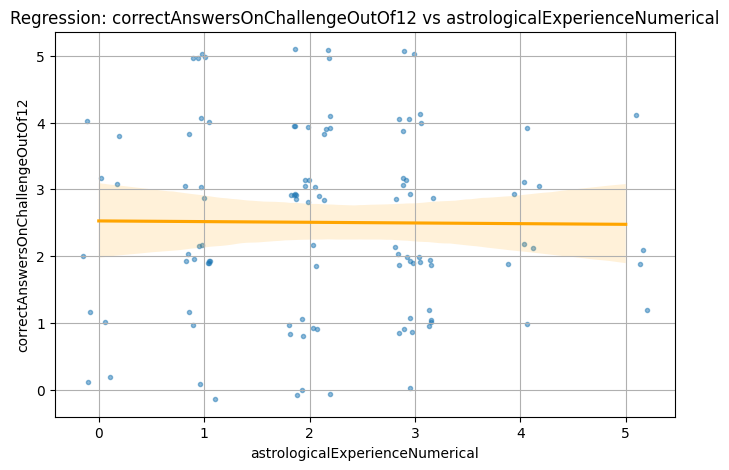

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

def perform_regression_analysis(df, x_col, y_col):
    # 1. Calculate Correlation (r) directly
    # This ensures the sign (+/-) matches the relationship
    r_value = df[x_col].corr(df[y_col])

    # 2. Prepare Data for Regression
    X = df[x_col]
    X_with_const = sm.add_constant(X) # adds the intercept
    Y = df[y_col]

    # 3. Fit the Model
    model = sm.OLS(Y, X_with_const).fit()

    # 4. Extract Key Statistics
    slope = model.params[x_col]
    intercept = model.params['const']
    p_value = model.pvalues[x_col]
    r_squared = model.rsquared
    std_error = model.bse[x_col] # Standard Error of the slope
    conf_int = model.conf_int().loc[x_col] # 95% Confidence Interval [lower, upper]

    # 5. Print Results Clearly
    print("--- REGRESSION SUMMARY ---")
    print(f"Correlation (r): {r_value:.4f}")
    print(f"R-squared:       {r_squared:.4f}")
    print(f"Slope (b1):      {slope:.4f}")
    print(f"Intercept (b0):  {intercept:.4f}")
    print(f"Standard Error:  {std_error:.4f}")
    print(f"95% CI:          [{conf_int[0]:.4f}, {conf_int[1]:.4f}]")
    print(f"p-value:         {p_value:.4f}")
    print("--------------------------")

    if p_value < 0.05:
        print("Result: Statistically Significant (Reject Null Hypothesis)")
    else:
        print("Result: Not Statistically Significant (Fail to Reject Null)")

    # 6. Visualization
    plt.figure(figsize=(8, 5))
    sns.regplot(x=x_col, y=y_col, data=df, ci=95,
                line_kws={'color': 'orange'}, scatter_kws={'alpha': 0.5}, marker=".",fit_reg=True,  x_jitter=0.2, y_jitter=0.2)
    # Corrected labels to match x_col and y_col used in sns.regplot
    plt.title(f"Regression: {y_col} vs {x_col}") # Dynamic title for consistency
    plt.xlabel(x_col) # Use column name as label
    plt.ylabel(y_col) # Use column name as label
    plt.grid(True) # Added grid lines
    plt.show()

# To run it on your data:
perform_regression_analysis(filtered_df, 'astrologicalExperienceNumerical', 'correctAnswersOnChallengeOutOf12')

In [27]:
import pandas
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as statsmodels # useful stats package with regression functions

#used this function from Minerva Guide
def mult_regression(x_col_names, y_col_name):
    # Ensure we use filtered_df for consistency with experience_data/answers_data context

    plt.figure()
    sns.regplot(x=filtered_df[x_col_names[0]], y=filtered_df[y_col_name], marker=".",fit_reg=True,color='orange', ci=None, x_jitter=0.2, y_jitter=0.2) # Changed marker for better visibility
    plt.title (f"Correct Answers vs. Astrological Experience")
    plt.xlabel('Astrological Experience (year)')
    plt.ylabel('Correct Answers')

    # define predictors X and response Y:
    X = filtered_df[x_col_names] # Use filtered_df and the list of column names
    X = statsmodels.add_constant(X)
    Y = filtered_df[y_col_name] # Use filtered_df and the column name

    # construct model:
    global regressionmodel
    regressionmodel = statsmodels.OLS(Y,X).fit() # OLS = "ordinary least squares"

    # residual plot:
    plt.figure()
    residualplot = sns.residplot(x=regressionmodel.predict(), y=regressionmodel.resid, color='green')
    residualplot.set(xlabel='Fitted values for '+y_col_name)
    residualplot.set(ylabel='Residuals')
    residualplot.set_title('Equal Variance: Residuals vs Fitted values')

    # QQ plot:
    qqplot = statsmodels.qqplot(regressionmodel.resid,fit=True,line='45')
    qqplot.suptitle("Normal (\"Q-Q\") Plot for Residuals")

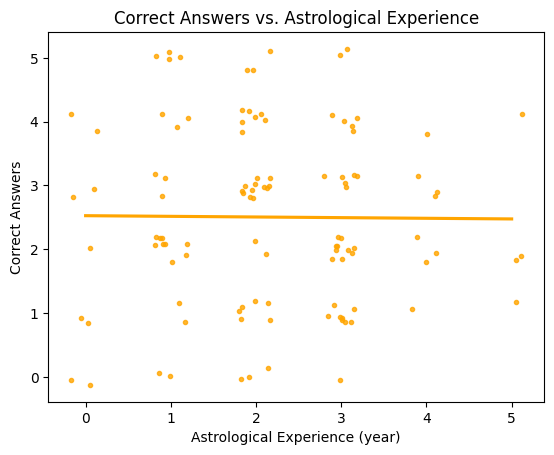

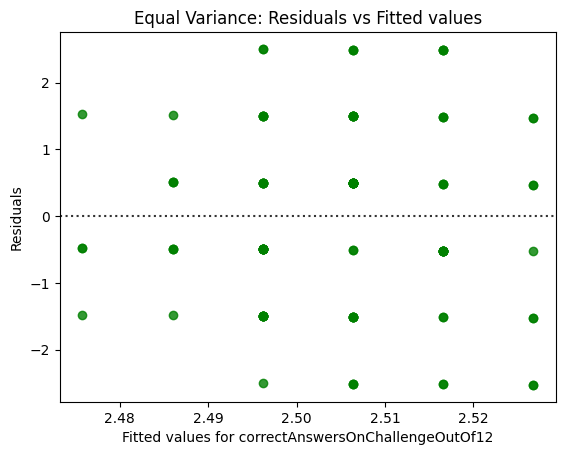

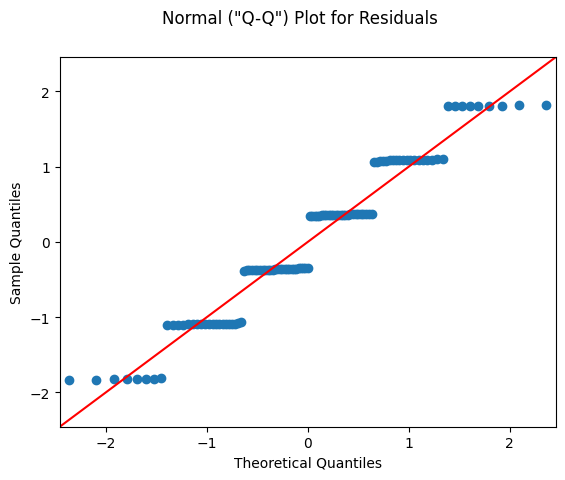

In [28]:
mult_regression(['astrologicalExperienceNumerical'], 'correctAnswersOnChallengeOutOf12')